In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path

In [2]:
RAW_DATA_DIR = Path("../data/raw")
PROCESSED_DATA_DIR = Path("../data/processed")

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
tickers = {
    "BTC": "BTC-USD",
    "ETH": "ETH-USD",
    "NASDAQ": "^NDX",
    "SP500": "^GSPC",
    "GOLD": "GC=F",
    "DXY": "DX-Y.NYB",
    "US10Y": "^TNX"
}

In [4]:
start_date = "2018-01-01"
end_date = None

data = yf.download(
    list(tickers.values()),
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

data.head()

Price              Close                                                   \
Ticker           BTC-USD   DX-Y.NYB     ETH-USD         GC=F        ^GSPC   
Date                                                                        
2018-01-01  13657.200195        NaN  772.640991          NaN          NaN   
2018-01-02  14982.099609  91.849998  884.443970  1313.699951  2695.810059   
2018-01-03  15201.000000  92.160004  962.719971  1316.199951  2713.060059   
2018-01-04  15599.200195  91.849998  980.921997  1319.400024  2723.989990   
2018-01-05  17429.500000  91.949997  997.719971  1320.300049  2743.149902   

Price                                   High                          ...  \
Ticker             ^NDX   ^TNX       BTC-USD   DX-Y.NYB      ETH-USD  ...   
Date                                                                  ...   
2018-01-01          NaN    NaN  14112.200195        NaN   782.530029  ...   
2018-01-02  6511.339844  2.465  15444.599609  92.250000   914.830017  ...   
2018-01-03  6575.799805  2.447  15572.799805  92.260002   974.471008  ...   
2018-01-04  6584.580078  2.453  15739.700195  92.260002  1045.079956  ...   
2018-01-05  6653.290039  2.476  17705.199219  92.099998  1075.390015  ...   

Price              Open                           Volume                       \
Ticker            ^GSPC         ^NDX   ^TNX      BTC-USD DX-Y.NYB     ETH-USD   
Date                                                                            
2018-01-01          NaN          NaN    NaN  10291200000      NaN  2595760128   
2018-01-02  2683.729980  6431.589844  2.433  16846600192      0.0  5783349760   
2018-01-03  2697.850098  6520.029785  2.451  16871900160      0.0  5093159936   
2018-01-04  2719.310059  6595.750000  2.473  21783199744      0.0  6502859776   
2018-01-05  2731.330078  6613.129883  2.465  23840899072      0.0  6683149824   

Price                                              
Ticker      GC=F         ^GSPC          ^NDX ^TNX  
Date                                               
2018-01-01   NaN           NaN           NaN  NaN  
2018-01-02  68.0  3.397430e+09  1.929700e+09  0.0  
2018-01-03  42.0  3.544030e+09  2.173130e+09  0.0  
2018-01-04   2.0  3.697340e+09  2.103220e+09  0.0  
2018-01-05   1.0  3.239280e+09  2.024000e+09  0.0  

[5 rows x 35 columns]

In [5]:
close_prices = data["Close"].copy()

# Rename columns from ticker symbols to readable asset names
reverse_tickers = {v: k for k, v in tickers.items()}
close_prices = close_prices.rename(columns=reverse_tickers)

close_prices.head()

Ticker,BTC,DXY,ETH,GOLD,SP500,NASDAQ,US10Y
Date,,,,,,,
2018-01-01,13657.200195,NaN,772.640991,NaN,NaN,NaN,NaN
2018-01-02,14982.099609,91.849998,884.443970,1313.699951,2695.810059,6511.339844,2.465
2018-01-03,15201.000000,92.160004,962.719971,1316.199951,2713.060059,6575.799805,2.447
2018-01-04,15599.200195,91.849998,980.921997,1319.400024,2723.989990,6584.580078,2.453
2018-01-05,17429.500000,91.949997,997.719971,1320.300049,2743.149902,6653.290039,2.476


In [6]:
missing_summary = close_prices.isna().sum().sort_values(ascending=False)
missing_summary

Ticker
SP500     958
NASDAQ    958
US10Y     958
GOLD      956
DXY       955
BTC         0
ETH         0
dtype: int64

In [7]:
# Forward fill missing values
close_prices_clean = close_prices.ffill()

# Remove rows that still contain any missing values
close_prices_clean = close_prices_clean.dropna()

close_prices_clean.head()

Ticker,BTC,DXY,ETH,GOLD,SP500,NASDAQ,US10Y
Date,,,,,,,
2018-01-02,14982.099609,91.849998,884.443970,1313.699951,2695.810059,6511.339844,2.465
2018-01-03,15201.000000,92.160004,962.719971,1316.199951,2713.060059,6575.799805,2.447
2018-01-04,15599.200195,91.849998,980.921997,1319.400024,2723.989990,6584.580078,2.453
2018-01-05,17429.500000,91.949997,997.719971,1320.300049,2743.149902,6653.290039,2.476
2018-01-06,17527.000000,91.949997,1041.680054,1320.300049,2743.149902,6653.290039,2.476


In [8]:
print("Shape:", close_prices_clean.shape)
print("Start date:", close_prices_clean.index.min())
print("End date:", close_prices_clean.index.max())

close_prices_clean.tail()

Shape: (3066, 7)
Start date: 2018-01-02 00:00:00
End date: 2026-05-26 00:00:00


Ticker,BTC,DXY,ETH,GOLD,SP500,NASDAQ,US10Y
Date,,,,,,,
2026-05-21,77539.171875,99.190002,2131.410645,4539.799805,7445.720215,29357.269531,4.586
2026-05-22,75488.242188,99.320000,2064.636963,4521.000000,7473.470215,29481.640625,4.558
2026-05-23,76673.367188,99.320000,2115.951416,4521.000000,7473.470215,29481.640625,4.558
2026-05-24,76981.125000,99.320000,2097.993896,4521.000000,7473.470215,29481.640625,4.558
2026-05-26,76680.187500,99.047997,2091.909912,4538.700195,7473.470215,29481.640625,4.558


In [9]:
output_path = PROCESSED_DATA_DIR / "multi_asset_prices.csv"

close_prices_clean.to_csv(output_path)

print(f"Saved to: {output_path}")

Saved to: ../data/processed/multi_asset_prices.csv


In [10]:
check_df = pd.read_csv(output_path)

check_df.head()

,Date,BTC,DXY,ETH,GOLD,SP500,NASDAQ,US10Y
0,2018-01-02,14982.099609,91.849998,884.443970,1313.699951,2695.810059,6511.339844,2.465
1,2018-01-03,15201.000000,92.160004,962.719971,1316.199951,2713.060059,6575.799805,2.447
2,2018-01-04,15599.200195,91.849998,980.921997,1319.400024,2723.989990,6584.580078,2.453
3,2018-01-05,17429.500000,91.949997,997.719971,1320.300049,2743.149902,6653.290039,2.476
4,2018-01-06,17527.000000,91.949997,1041.680054,1320.300049,2743.149902,6653.290039,2.476


In [11]:
prices = pd.read_csv(
    "../data/processed/multi_asset_prices.csv",
    index_col=0,
    parse_dates=True
)

prices.head()

,BTC,DXY,ETH,GOLD,SP500,NASDAQ,US10Y
Date,,,,,,,
2018-01-02,14982.099609,91.849998,884.443970,1313.699951,2695.810059,6511.339844,2.465
2018-01-03,15201.000000,92.160004,962.719971,1316.199951,2713.060059,6575.799805,2.447
2018-01-04,15599.200195,91.849998,980.921997,1319.400024,2723.989990,6584.580078,2.453
2018-01-05,17429.500000,91.949997,997.719971,1320.300049,2743.149902,6653.290039,2.476
2018-01-06,17527.000000,91.949997,1041.680054,1320.300049,2743.149902,6653.290039,2.476


In [12]:
normalized_prices = prices / prices.iloc[0] * 100

normalized_prices.head()

,BTC,DXY,ETH,GOLD,SP500,NASDAQ,US10Y
Date,,,,,,,
2018-01-02,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2018-01-03,101.461080,100.337512,108.850306,100.190302,100.639882,100.989965,99.269781
2018-01-04,104.118919,100.000000,110.908326,100.433895,101.045323,101.124811,99.513191
2018-01-05,116.335497,100.108872,112.807595,100.502405,101.756053,102.180046,100.446254
2018-01-06,116.986273,100.108872,117.777959,100.502405,101.756053,102.180046,100.446254


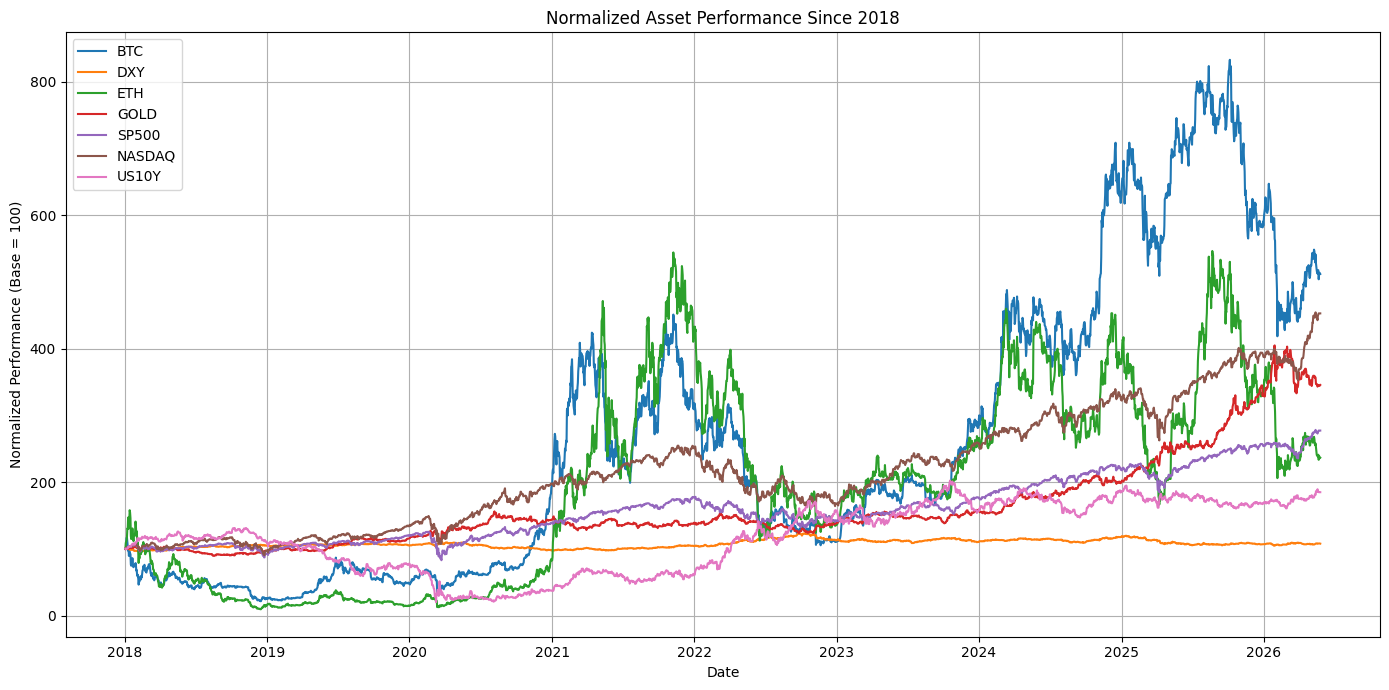

In [13]:
plt.figure(figsize=(14, 7))

for column in normalized_prices.columns:
    plt.plot(
        normalized_prices.index,
        normalized_prices[column],
        label=column
    )

plt.title("Normalized Asset Performance Since 2018")
plt.xlabel("Date")
plt.ylabel("Normalized Performance (Base = 100)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [14]:
returns = close_prices_clean.pct_change().dropna()

returns.head()

Ticker,BTC,DXY,ETH,GOLD,SP500,NASDAQ,US10Y
Date,,,,,,,
2018-01-03,0.014611,0.003375,0.088503,0.001903,0.006399,0.009900,-0.007302
2018-01-04,0.026196,-0.003364,0.018907,0.002431,0.004029,0.001335,0.002452
2018-01-05,0.117333,0.001089,0.017125,0.000682,0.007034,0.010435,0.009376
2018-01-06,0.005594,0.000000,0.044061,0.000000,0.000000,0.000000,0.000000
2018-01-07,-0.059873,0.000000,0.107029,0.000000,0.000000,0.000000,0.000000


In [15]:
summary_stats = returns.describe().T

summary_stats

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
BTC,3065.0,0.001102,0.033539,-0.371695,-0.013498,0.000695,0.015125,0.187465
DXY,3065.0,0.000031,0.003482,-0.021167,-0.001118,0.000000,0.001320,0.016525
ETH,3065.0,0.001261,0.043979,-0.423472,-0.019185,0.000489,0.021132,0.259475
GOLD,3065.0,0.000445,0.008965,-0.113662,-0.001625,0.000000,0.003460,0.060833
SP500,3065.0,0.000384,0.010120,-0.119841,-0.001592,0.000000,0.003616,0.095154
NASDAQ,3065.0,0.000572,0.012581,-0.121932,-0.001925,0.000000,0.005138,0.120223
US10Y,3065.0,0.000542,0.026466,-0.293201,-0.006144,0.000000,0.006665,0.498998


In [16]:
annualized_volatility = returns.std() * np.sqrt(252)

annualized_volatility.sort_values(ascending=False)

Ticker
ETH       0.698151
BTC       0.532412
US10Y     0.420139
NASDAQ    0.199716
SP500     0.160645
GOLD      0.142309
DXY       0.055274
dtype: float64

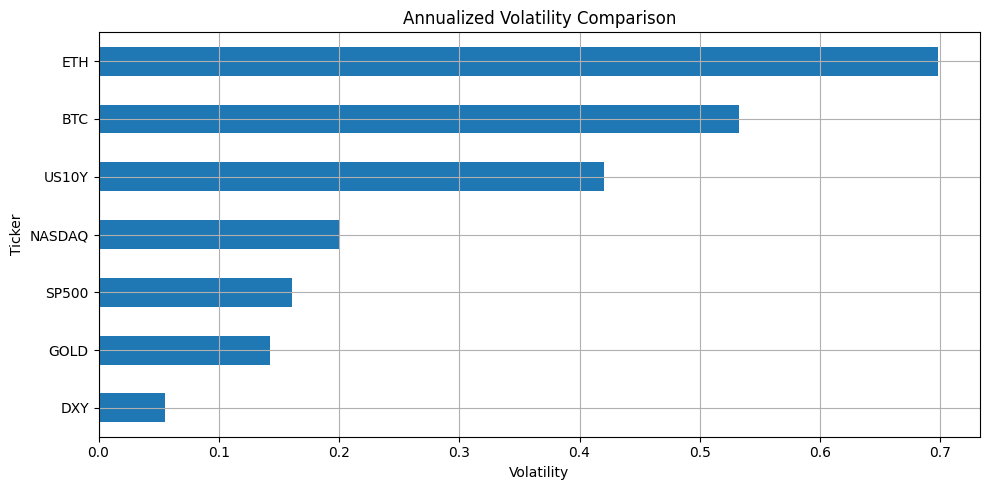

In [17]:
annualized_volatility.sort_values().plot(
    kind="barh",
    figsize=(10, 5)
)

plt.title("Annualized Volatility Comparison")
plt.xlabel("Volatility")
plt.grid(True)

plt.tight_layout()
plt.show()

In [18]:
correlation_matrix = returns.corr()

correlation_matrix

Ticker,BTC,DXY,ETH,GOLD,SP500,NASDAQ,US10Y
Ticker,,,,,,,
BTC,1.000000,-0.106275,0.816807,0.091450,0.281266,0.292719,0.012221
DXY,-0.106275,1.000000,-0.097915,-0.387410,-0.149727,-0.133532,0.209379
ETH,0.816807,-0.097915,1.000000,0.076226,0.296007,0.305837,0.009135
GOLD,0.091450,-0.387410,0.076226,1.000000,0.086719,0.088850,-0.207809
SP500,0.281266,-0.149727,0.296007,0.086719,1.000000,0.939010,0.249985
NASDAQ,0.292719,-0.133532,0.305837,0.088850,0.939010,1.000000,0.159051
US10Y,0.012221,0.209379,0.009135,-0.207809,0.249985,0.159051,1.000000


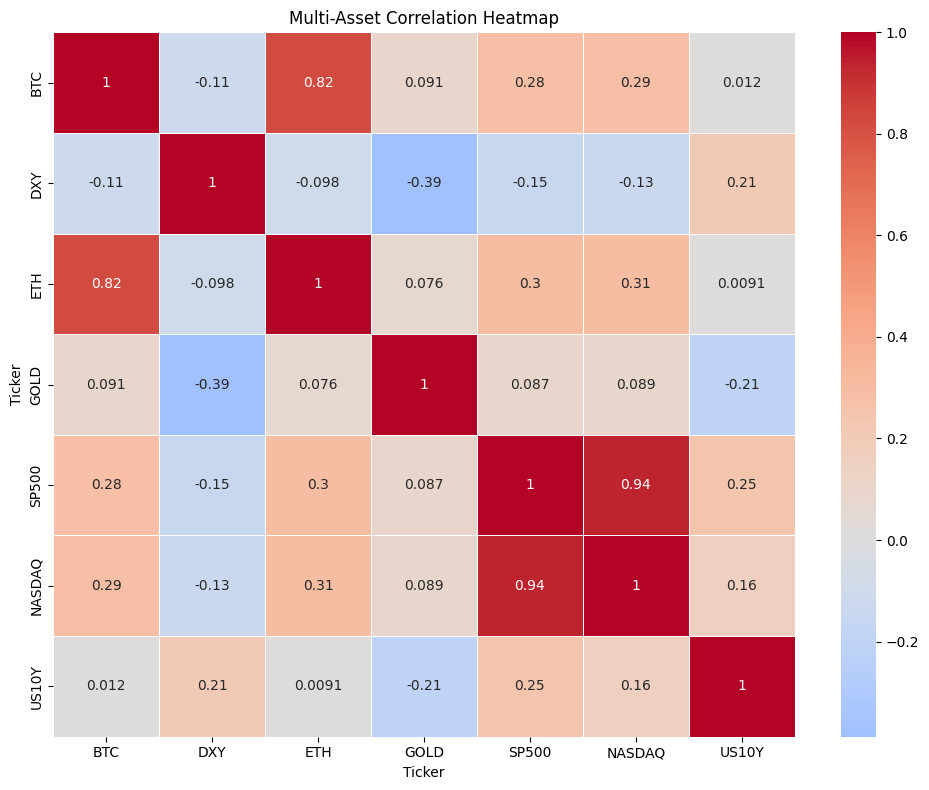

In [19]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Multi-Asset Correlation Heatmap")

plt.tight_layout()
plt.show()

In [20]:
rolling_window = 90

btc_nasdaq_corr = (
    returns["BTC"]
    .rolling(rolling_window)
    .corr(returns["NASDAQ"])
)

btc_sp500_corr = (
    returns["BTC"]
    .rolling(rolling_window)
    .corr(returns["SP500"])
)

btc_gold_corr = (
    returns["BTC"]
    .rolling(rolling_window)
    .corr(returns["GOLD"])
)

btc_dxy_corr = (
    returns["BTC"]
    .rolling(rolling_window)
    .corr(returns["DXY"])
)

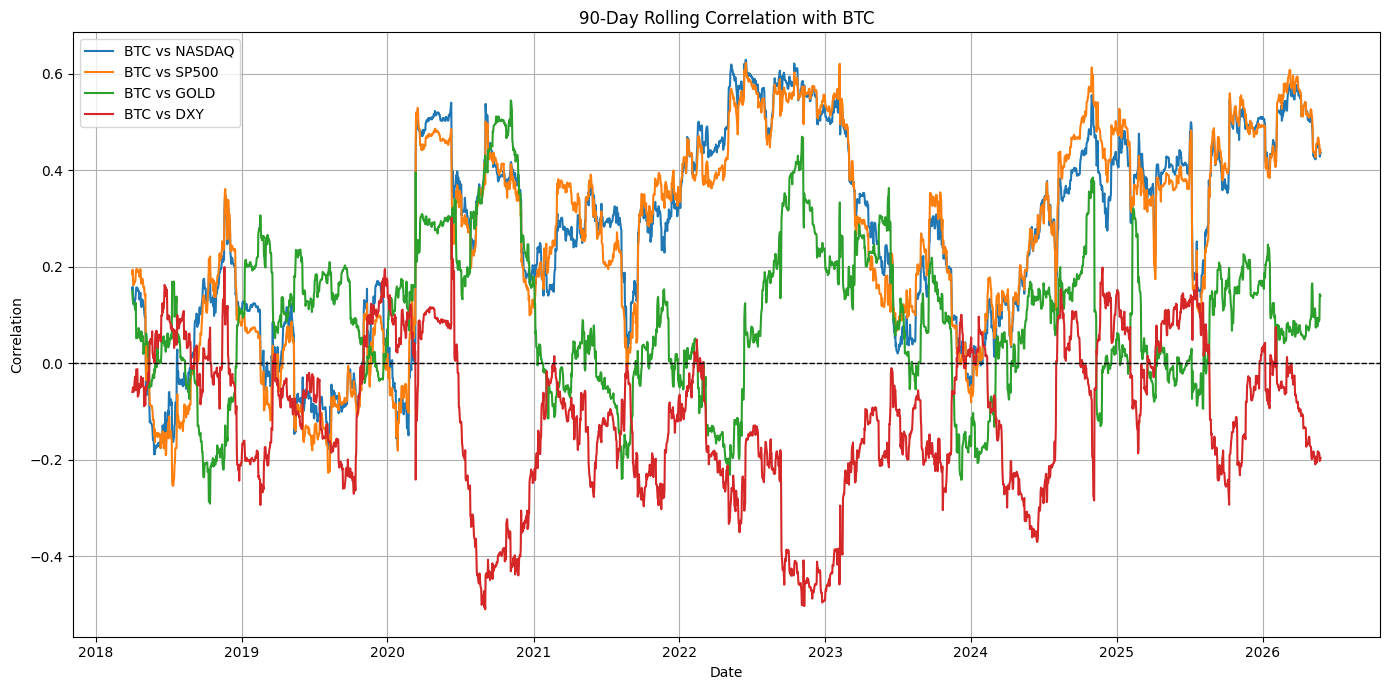

In [21]:
plt.figure(figsize=(14, 7))

plt.plot(
    btc_nasdaq_corr,
    label="BTC vs NASDAQ"
)

plt.plot(
    btc_sp500_corr,
    label="BTC vs SP500"
)

plt.plot(
    btc_gold_corr,
    label="BTC vs GOLD"
)

plt.plot(
    btc_dxy_corr,
    label="BTC vs DXY"
)

plt.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title("90-Day Rolling Correlation with BTC")

plt.xlabel("Date")
plt.ylabel("Correlation")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Multi-Asset Market Insights

This analysis explores how Bitcoin behaves relative to major macro and traditional financial assets including:

- Ethereum
- Nasdaq
- S&P 500
- Gold
- US Dollar Index (DXY)
- US 10-Year Yield

The objective is to understand whether Bitcoin behaves more like:
- a speculative technology asset,
- a macro liquidity asset,
- or a defensive store of value.

## Volatility Analysis

Ethereum and Bitcoin exhibited the highest annualized volatility among all analyzed assets.

Key observations:
- Ethereum demonstrated the highest volatility overall, confirming its higher-beta behavior relative to Bitcoin.
- Bitcoin remained significantly more volatile than equities and commodities.
- Traditional macro assets such as DXY and Gold showed much lower volatility.
- US10Y volatility increased substantially during the post-2021 tightening cycle, reflecting aggressive interest rate repricing.

This suggests that crypto markets remain highly sensitive to liquidity conditions and speculative capital flows.

## Correlation Analysis

The correlation matrix revealed several important macro relationships:

- Bitcoin and Ethereum maintained a strong positive correlation, indicating shared crypto market risk exposure.
- Nasdaq and S&P 500 showed extremely high correlation due to overlapping equity market exposure.
- Bitcoin displayed only moderate positive correlation with US equities over the full sample period.
- Bitcoin maintained weak long-term correlation with Gold, challenging the narrative that Bitcoin consistently behaves as "digital gold."
- DXY generally maintained negative correlation with risk assets, including Bitcoin and equities.

These findings suggest Bitcoin behaves more similarly to a high-risk liquidity-sensitive asset than a defensive macro hedge.

## Rolling Correlation Regime Analysis

Rolling 90-day correlations demonstrated that Bitcoin's relationship with traditional assets changes significantly across market regimes.

Key findings:
- Bitcoin became increasingly correlated with Nasdaq and S&P 500 during liquidity-driven market cycles.
- During risk-on environments, Bitcoin behaved similarly to speculative growth assets.
- Bitcoin's correlation with DXY frequently turned negative during tightening periods and stronger US dollar environments.
- Correlation with Gold remained unstable and inconsistent throughout the analysis period.

This indicates Bitcoin's macro identity is dynamic rather than fixed.

# Conclusion

This project demonstrates that Bitcoin cannot be consistently classified as:
- purely digital gold,
- purely independent,
- or purely a technology asset.

Instead, Bitcoin behaves as a hybrid macro-sensitive asset whose behavior changes depending on:
- global liquidity conditions,
- monetary policy,
- market risk appetite,
- and institutional participation.

The analysis also highlights the increasing integration of crypto markets with traditional financial systems since 2020.